# Phase Three: Finding Anomaly Years

Using our engineered features, we now explore our data further in an effort to find years that can be considered anomalous. Intuitively, in agriculture, a year will be considered anomalous when:

- High shortage and low precipitation, leading to drought stress.
- Above average, precipitation especially flooding rains which are common occurances.
- Low vegetation even when environmental factors aren't completely abnormal.



## Libraries

In [40]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent / "src"))


In [41]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid", context="notebook", palette="muted")

import plotly.express as px
import plotly.io as pio
pio.renderers.default = "plotly_mimetype"

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import IsolationForest

from data import DatasetLoader, DatasetBuilder, utils


## Load Data

In [42]:
loader = DatasetLoader(raw_data_dir="../data/raw/", engineered_data_dir="../data/processed/")
non_spectral_df = loader.non_spectral()
grouped_spectral_df = loader.grouped_spectral()
master_df = utils.merge_with_master(grouped_spectral_df, non_spectral_df)
master_df.head()

In [43]:
# Engineered features
eng_non_spectral_df  = pd.read_csv("../data/processed/eng_non_spectral_df.csv", index_col=0)
eng_non_spectral_df["Timestamp"] = pd.to_datetime(eng_non_spectral_df["Timestamp"])

eng_non_spectral_df["in_season"] = eng_non_spectral_df["in_season"].astype('category')
eng_non_spectral_df["Growth_Stage"] = eng_non_spectral_df["Growth_Stage"].astype('category')

# Rolling statistics and lagged variables
roll_lag_df = pd.read_csv("../data/processed/roll_lag_df.csv", index_col=0)
roll_lag_df["Timestamp"] = pd.to_datetime(roll_lag_df["Timestamp"])

In [44]:
def get_interpolated_df(spectral, timestamps):
    spectral_columns = [
        'NDVI_mean',
        'NDWI_mean',
        'NDRE_mean',
        'NDVI_std',
        'NDWI_std',
        'NDRE_std',
    ]

    df = spectral.merge(timestamps, on="Timestamp", how="right")
    interpolated_df = df[["Timestamp"] + spectral_columns].copy()
    interpolated_df[spectral_columns] = interpolated_df[spectral_columns].interpolate(method="pchip", limit_area="inside").bfill()

    return interpolated_df.dropna()

---

## Per-year analysis

### Summary Statistics

A good first approach to looking at how our growing seasons are distributed is considering the sample mean, cummulation or order statistics of specific features. This will give us a good idea of which years deviate from an expected trend.

In [45]:
eng_features = [
    'precipitation',
    'cumulative_GDD',
    'temperature_2m',
    'root_weighted_soil_moisture',
    "Shallow_mean",
    'Ag_year',
    'shifted_doy',
    
]

spectral_features = [
    'NDVI_mean',
    'NDWI_mean',
    'NDRE_mean',
    'NDVI_std',
    'NDWI_std',
    'NDRE_std',
]

In [46]:
# Get df containing above features

interpolated_df = get_interpolated_df(
    spectral=grouped_spectral_df, 
    timestamps=eng_non_spectral_df["Timestamp"]
)

summary_df = pd.merge(interpolated_df, eng_non_spectral_df, on="Timestamp")

mask = (summary_df["in_season"] == 1) & (summary_df["Ag_year"] != 2017)
summary_df = summary_df[mask]

In [47]:
grouped = summary_df.drop('shifted_doy', axis=1).groupby("Ag_year")

agg = grouped.agg({
    "precipitation": "sum",
    "temperature_2m": "mean",
    "root_weighted_soil_moisture": "mean",
    "cumulative_GDD": "max",
    "NDVI_mean": "mean",
    "NDWI_mean": "mean",
    "NDRE_mean": "mean",
}).reset_index()
agg

,Ag_year,precipitation,temperature_2m,root_weighted_soil_moisture,cumulative_GDD,NDVI_mean,NDWI_mean,NDRE_mean
0,2018,616.547833,290.730678,0.287340,1926.859178,0.409582,0.067484,0.271515
1,2019,537.903352,289.719104,0.293197,1702.141394,0.429904,0.116318,0.282203
2,2020,669.932304,289.138301,0.377099,1546.787355,0.456460,0.171278,0.299337
3,2021,686.550234,288.681646,0.366703,1439.989890,0.462735,0.148522,0.301380
4,2022,698.384335,288.895480,0.368016,1477.107679,0.468064,0.164780,0.302569
5,2023,595.111969,290.256479,0.302184,1820.998342,0.429436,0.096275,0.281179
6,2024,823.606560,289.551048,0.366058,1668.667770,0.468810,0.162550,0.296305


From this summary table, we conclude the following:
- **Total precipitation** has strong fluctuations, with a _low_ of $538$mm (2019), $595$mm (2023) and a _high_ of ~$824$mm for 2024.
- **NDWI** can be seen as a water stress proxy, with a strong dip in 2018 at $0.067$ and 2023 at $0.096$. 2019 also has a noteworthy low NDWI value.
- The highest cumulative GDD seasons are 2018 and 2023 with values ~$1927$ and ~$1821$ respectively. Since each season has the same End of Season (EoS) DOY by design, 2018 and 2023 consistently had higher heat-accumulation. 

We can come to the conclustion that 2018 and 2023 are our most stressed seasons, with 2019 a close third place. Stress in this case is defined as heat-accumulation and drought.

### NDVI

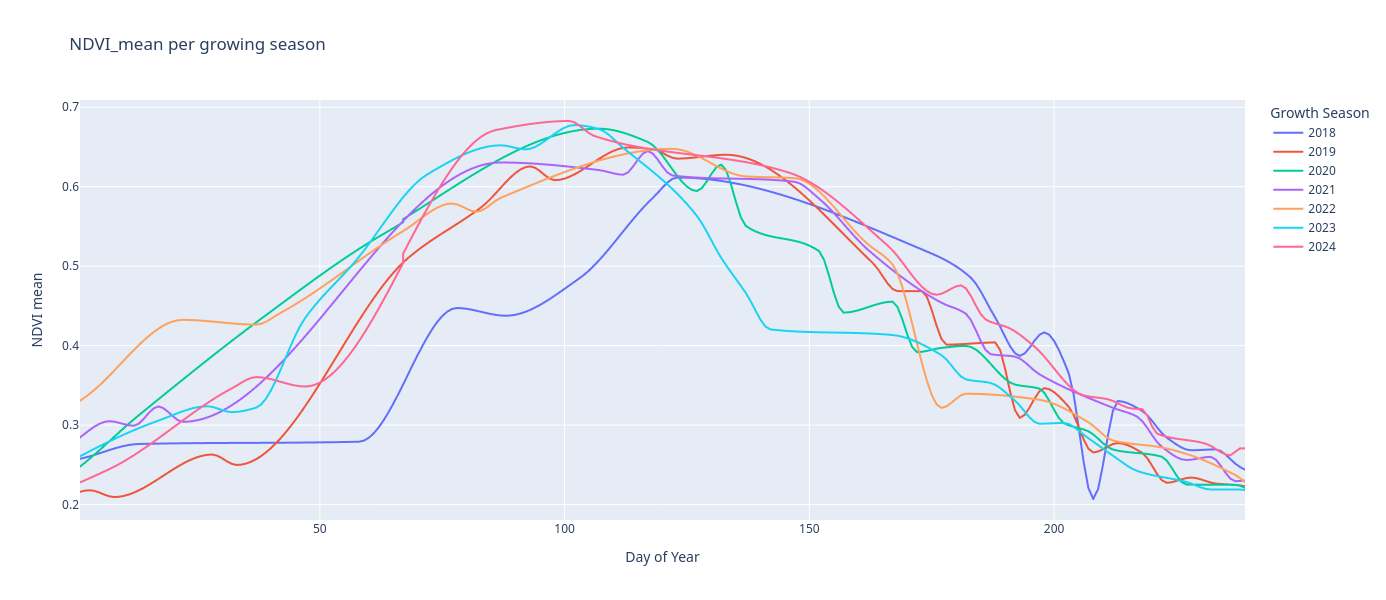

In [48]:

fig = px.line(
    summary_df, 
    x="shifted_doy", 
    y="NDVI_mean", 
    color="Ag_year",
    title="NDVI_mean per growing season",
    labels={"shifted_doy": "Day of Year", "NDVI_mean": "NDVI mean", "Ag_year": "Growth Season"},
    template="plotly_white",
    height=600,
    width=1000,
)
fig.update_layout(template="plotly")
fig.update_layout(hovermode="x unified")


fig.show()

### Z-scores

A useful processing technique is calculating the $Z$-scores of _each feature_, grouped over our defined growing seasons. More specifically, if $\textbf{x}_\text{year}$ represents a **feature vector** in a specific growing season, we scale and standardise each feature $j=1,2,...,p$ so that its mean is $0$ and variance is $1$. 
$$
z_{\text{year},j} = \frac{x_{\text{year}, j}-\bar{x}_{\text{year},j}}{s_{\text{year}, j}}
$$

This removes seasonal scale differences, allowing for the comparison of features across _seasons_. We first show the usefulness with a heatmap: 

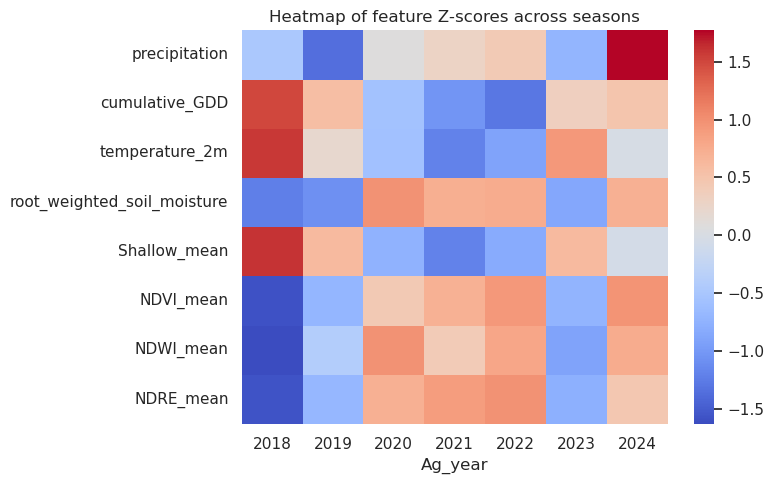

In [49]:
yearly = summary_df.groupby("Ag_year")[eng_features[:-2] + spectral_features[:-3]].mean()
yearly_z = (yearly - yearly.mean()) / yearly.std()

plt.figure(figsize=(8, 5))
plt.title("Heatmap of feature Z-scores across seasons")
sns.heatmap(yearly_z.T, cmap="coolwarm")
plt.tight_layout()
plt.show()

Here we can find which variables were unusally high/low relative to each season's own baseline. We again see the pattern we found in the summary statistics:
- 2018-2019 have _strong_ **positive** deviation from their own baselines for air temperature, shallow soil temperature and cummulative GDD.
- 2018-2019 have **negative** deviations from their baselines for precipitation, $\text{NDWI}$ and root weighted soil moisture (water uptake of roots from soil, dependent on growth stage). Additionally, vegetation indices like $\text{NDRE}/\text{NDVI}$ also have _strong_ negative deviations, suggesting crop stress.
- 2020-2022, 2025 are recovery periods.
- 2023 again shows signs of stress, with **negative** deviations from the spectral indices $\text{NDWI}$ (water proxy), $\text{NDRE}$ / $\text{NDVI}$ (greenness/chlorophyl), suggesting stress in the vegetation.

We can make these deviations slightly more interpretable with barplots:

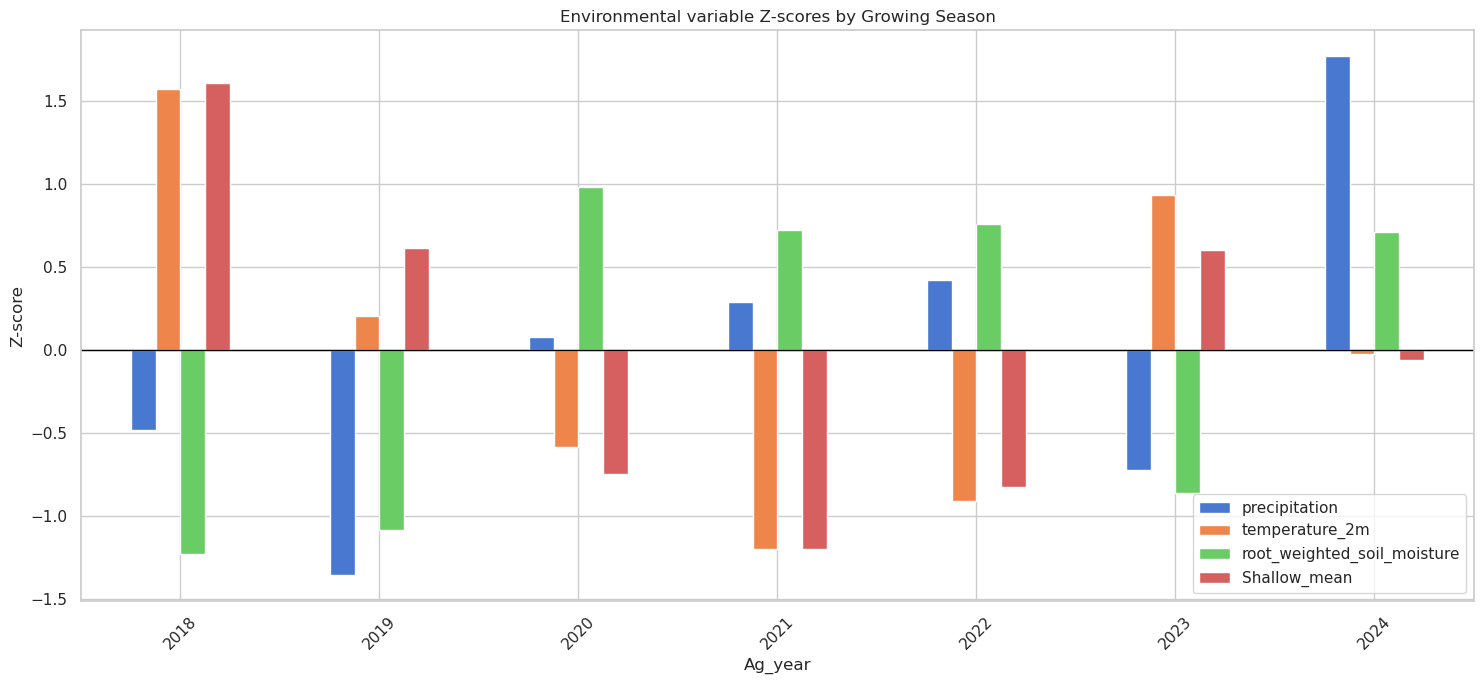

In [50]:
selected = ["precipitation", "temperature_2m", "root_weighted_soil_moisture", "Shallow_mean"]

yearly_z[selected].plot(kind="bar", figsize=(15, 7))
plt.axhline(0, color="black", linewidth=1)
plt.title("Environmental variable Z-scores by Growing Season")
plt.ylabel("Z-score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

And our spectral indices can be visualised in a similar way:

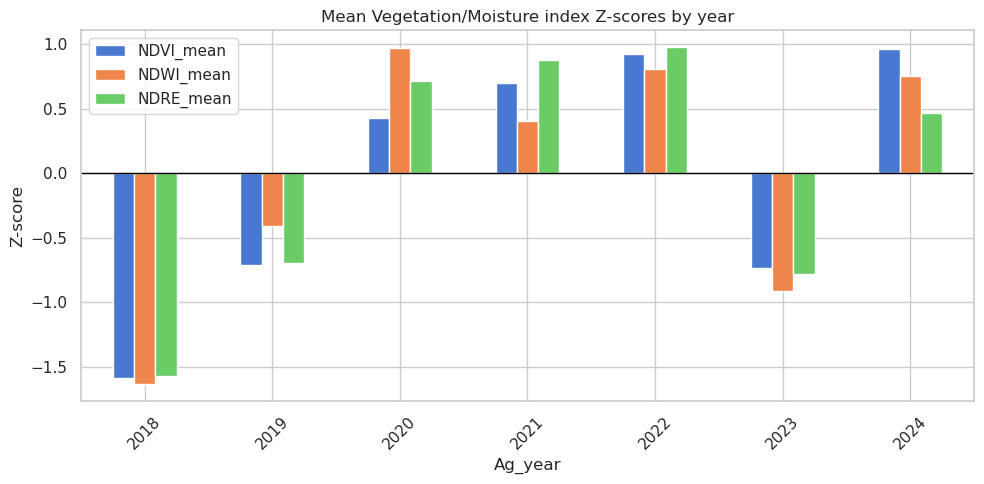

In [51]:
spectral_means = ["NDVI_mean", "NDWI_mean", "NDRE_mean"]

fig, ax = plt.subplots(figsize=(10, 5))

yearly_z[spectral_means].plot(kind="bar", ax=ax)
ax.axhline(0, color="black", linewidth=1)
ax.set_title("Mean Vegetation/Moisture index Z-scores by year")
ax.set_ylabel("Z-score")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

---

## PCA

Let $X$ represent the `summary_df` dataframe grouped by growing season (`Ag_year`), with the mean of each feature $j=1,2,...p$ calculated. If we center this dataset to get $X_c$, the covariance matrix is given by $$\Sigma=\frac{1}{T-1} X_c'X_c$$
where $T$ is the number of years. This measures how **yearly** averages of different variables co-vary across years. By definition, it follows the **first** principal component of $X_c$ is the direction explaining the most variation between yearly _means_ - and the **second** is orthogonal to the first, explaining the largest remaining variance among yearly means, etc.

To show why this explanation is important, let's first find a 2-dimensional representation of our data. 

In [52]:
eng_features = [
    'precipitation',
    'cumulative_GDD',
    'temperature_2m',
    'root_weighted_soil_moisture',
    'Shallow_mean',
    "ST_PC1",
    "VW_PC1",
    "Ag_year"
]

spectral_features = [
    'NDVI_mean',
    'NDWI_mean',
    'NDRE_mean',
]

In [53]:
# get summary dataframe containing selected features

interpolated_df = get_interpolated_df(
    spectral=grouped_spectral_df, 
    timestamps=eng_non_spectral_df["Timestamp"]
)

summary_df = pd.merge(interpolated_df, eng_non_spectral_df, on="Timestamp")

mask = (summary_df["in_season"] == 1) & (summary_df["Ag_year"] != 2017)
summary_df = summary_df[mask]

In [54]:
pca = PCA()
scaler = StandardScaler()

X = summary_df[eng_features + spectral_features].groupby("Ag_year").mean() 
X_scaled = scaler.fit_transform(X)

pca.fit(X_scaled)
explained_variance = pca.explained_variance_ratio_ * 100
cumulative_variance = np.cumsum(explained_variance)

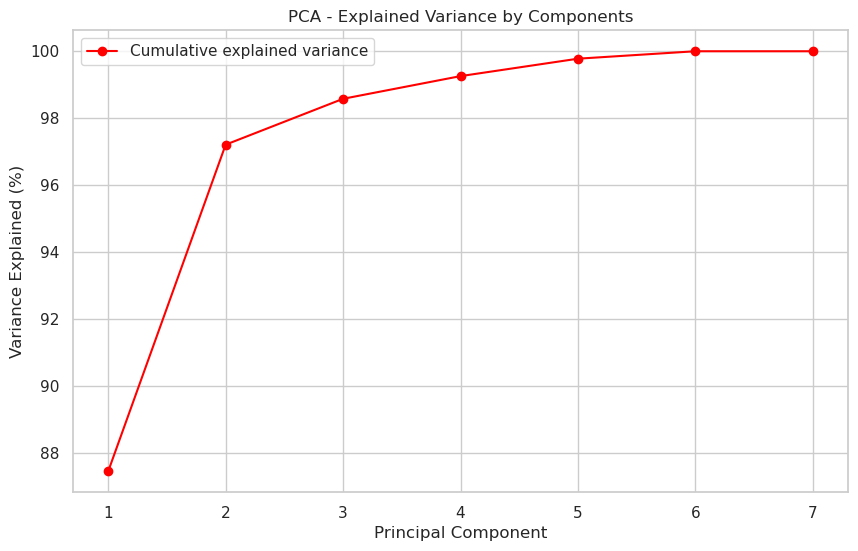

In [55]:
plt.figure(figsize=(10, 6))

components = np.arange(1, len(explained_variance) + 1)

plt.plot(components, cumulative_variance, marker='o', color='red', label='Cumulative explained variance')

plt.xlabel('Principal Component')
plt.ylabel('Variance Explained (%)')
plt.title('PCA - Explained Variance by Components')
plt.xticks(components)
plt.legend()
plt.grid(True)

plt.show()

Conveniently, 2 components explain ~$97\%$ of our yearly means. To interpret this new two dimensional representation, note that the **scores** are defined as the coordinates of the data points along the new components and the **loadings** are the coefficients that define the principal component.

In [56]:
pca = PCA(n_components=2).fit(X_scaled)
loadings = pd.DataFrame(pca.components_.T, index=X.columns, columns=["PC1", "PC2"])

loadings.sort_values("PC1", ascending=False)

,PC1,PC2
NDRE_mean,0.337753,-0.027020
VW_PC1,0.332125,0.166444
NDVI_mean,0.328639,0.174497
root_weighted_soil_moisture,0.327046,0.177389
NDWI_mean,0.322512,0.081229
precipitation,0.221877,0.749077
cumulative_GDD,-0.298944,0.417249
temperature_2m,-0.319536,0.272961
ST_PC1,-0.328564,0.214437
Shallow_mean,-0.328611,0.217596


**PC 1**:

An interesting thing to note for PC1 is that each feature's corresponding loading magnitutde is very similar $\approx 0.3 \text{ to } 0.33$, differing only by sign. In a sense this can be seen as two groups with a positive and negative direction, respectively. In other words, the **positive direction** is represented by vegetation and moisture, (e.g. NDVI, NDWI, Root-zone soil moisture, etc.) - the **negative direction** is represented by heat and surface-temperature (e.g. temperature 2m, shallow mean soil temperature). A high PC1 score corresponds to higher vegetation indices, higher moisture and lower temperature. A low (or negative) PC1 score represents the opposite.

**PC 2**:

This component is dominated by precipitation with a magnitutde of $0.75$, followed by cumulative GDD with a magnitutde of $0.42$. This is largely a precipitation axis.

We now look at the **scores** of each year, i.e. the 2D representation of the yearly means in the new coordinate system.

In [57]:
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"], index=X.index).reset_index()

scores = pd.DataFrame(X_pca, columns=["PC1", "PC2"], index=X.index)
scores

,PC1,PC2
Ag_year,,
2018,-4.940777,0.600357
2019,-2.396118,-1.014974
2020,2.287216,-0.247890
2021,2.959403,-0.711425
2022,2.896400,-0.407372
2023,-2.448404,-0.357182
2024,1.642280,2.138486


We have a few standouts:
1. 2024 has a PC2 score of $2.138$, which is much higher than any other year. This year appears to have been unusually wet relative to the others.
2. 2018 has the lowest PC1 score with a coordinate value $-4.94$. This suggests it was an extremely hot / low vegetation year.
3. Similarly, 2019 and 2023 were both hot and dry as well.

To put this all together, consider the plot of our data points in the new coordinate system.

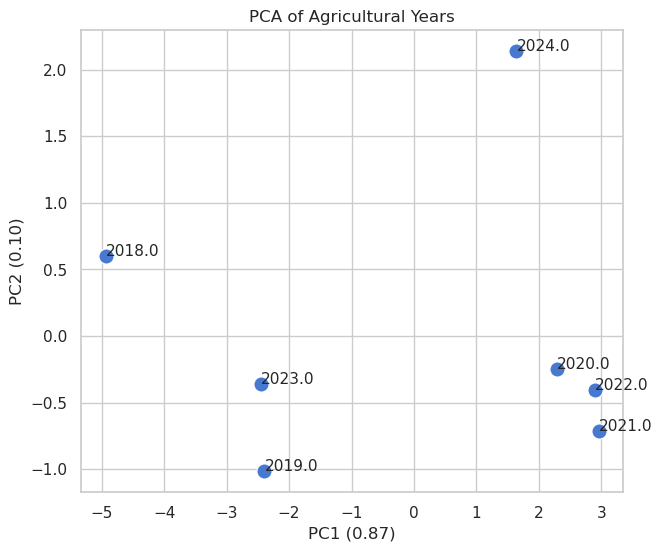

In [58]:
plt.figure(figsize=(7,6))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", s=120)

for _, row in pca_df.iterrows():
    plt.text(row["PC1"], row["PC2"], row["Ag_year"], fontsize=11)

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.2f})")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.2f})")
plt.title("PCA of Agricultural Years")
plt.show()


The clearly outlying data points are:
- 2018, with poor vegetation, high heat and moderate precipitation.
- 2023 and 2019, with poor vegetation and low precipitation.
- 2024 with high vegetation, lower temperatures and extreme precipitation.

---

# Isolation Forest

Isolation Forests are unique in that they provide us with a unassuming ensemble model that evaluates expected path lengths of orthogonal (uniformly split) partitions across the feature space. It can't overfit in the traditional sense since there is no loss function to optimise. For anomalous data, the _path length_ of $x$ (i.e. number of traversals of $x$ along the edges to get to termination node) will consistently be short across the ensemble. This is because an outlier sits very far out in a high dimensional space, so it has a higher probability of being split from the cluster.

In [59]:
features = [
    'NDVI_mean', 
    'NDWI_mean', 
    'NDRE_mean', 
    'volumetric_soil_water_layer_4', 
    #'soil_temperature_level_4', 
    'temperature_2m', 
    #'temperature_2m_min',
    #'temperature_2m_max', 
    'surface_solar_radiation_downwards_sum',
    'precipitation', 
    'cumulative_GDD', 
    'root_weighted_soil_moisture', 
    #'VW_PC1',
    #'Shallow_mean', 
    'ST_PC1'
]

In [60]:
yearly = summary_df.groupby("Ag_year")[features].mean()

In [61]:
yearly = summary_df.groupby("Ag_year").agg({
    "NDVI_mean": ["mean"],
    "NDWI_mean": ["mean"],
    "NDRE_mean": ["mean"],
    "precipitation": ["sum"],
    "temperature_2m": ["mean", "max"],
    "root_weighted_soil_moisture": ["mean", "min"],
    'ST_PC1': ['mean', 'max'],
    'surface_solar_radiation_downwards_sum': ['mean'],
    'cumulative_GDD': ["max"],
    'soil_temperature_level_4': ["mean"],
    'volumetric_soil_water_layer_4': ["mean"]
})

In [62]:
scaler = StandardScaler()

X = yearly.copy()
X_scaled = scaler.fit_transform(X)

model = IsolationForest(n_estimators=100000, contamination=3/7)
model.fit(X_scaled)

yearly["anomaly_label"] = model.predict(X_scaled)
yearly["anomaly_score"] = model.decision_function(X_scaled)

In [63]:
yearly[["anomaly_score", "anomaly_label"]]

,anomaly_score,anomaly_label
,,
Ag_year,,
2018,-0.096836,-1
2019,-0.013140,-1
2020,0.003480,1
2021,0.009088,1
2022,0.019260,1
2023,-0.002338,-1
2024,0.001753,1


The isolation forest therefore agrees with our findings that 2018, 2019 and 2023 were anomaly years, with 2024 being a runner-up with its near-zero anomaly score.

---